# Imports

In [1]:
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from rich import print

import matplotlib.pyplot as plt
import seaborn as sns

# Init Spark


In [2]:
spark = SparkSession.builder \
    .appName("NCEI_Weather_Analysis") \
    .master("local") \
    .getOrCreate()
# local[*] for all cores
spark.sparkContext.setLogLevel("ERROR")

print("[green](*)[/green] Spark is running!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/24 20:30:47 WARN Utils: Your hostname, Melovka.local, resolves to a loopback address: 127.0.0.1; using 10.10.205.26 instead (on interface en0)
26/03/24 20:30:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/24 20:30:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


(*) Spark is running!

# Data

- Get Weather Data from Cincinnati & Florida from [NCEI.nooa.gov](https://www.ncei.noaa.gov/data/global-summary-of-the-day/access/)
- Required data:
    - Cincinnati (72429793812) from 2015 - 2024
    - Florida (99495199999) from 2015 - 2024 (note that 2016 Florida data does not exist)

In [3]:
# script to download the required data
def download_weather_data(city_code, start_year, end_year, output_dir):
    """
    Downloads weather data for a given city and time range, and saves it to the specified output directory.

    Args:
        city_code (str): The code of the city for which to download weather data.
        start_year (int): The starting year of the data to download.
        end_year (int): The ending year of the data to download.
        output_dir (str): The directory where the downloaded data should be saved.
    
    Returns:
        None
    """

    # make sure output directory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    for year in range(start_year, end_year + 1):
        # construct the URL of ncei.noaa.gov for the specified city and time range
        url = f"https://www.ncei.noaa.gov/data/global-summary-of-the-day/access/{year}/{city_code}.csv"
        # download the data and save it to the output directory
        sub_dir = os.path.join(output_dir, f"year={year}")
        if not os.path.exists(sub_dir):
            os.makedirs(sub_dir)
        output_file = os.path.join(sub_dir, f"{city_code}.csv")
        try:
            # -f flag tells curl to return an error code on 404
            exit_code = os.system(f"curl -f -o {output_file} {url} --silent")   
            
            if exit_code == 0:
                print(f"[green](*)[/green] Data for {city_code} in {year} has been downloaded and saved to {output_file}.")
            else:
                print(f"[red](!)[/red] Failed to download data for {city_code} in {year}. (Likely 404 Not Found)")
                # remove the empty file curl might have created before failing
                if os.path.exists(output_file):
                    os.remove(output_file)
        except Exception as e:
            print(f"[red](!)[/red] An error occurred while downloading data for {city_code} in {year}: {e}")

In [4]:
# run the script to download the data for the specified city and time range
CINCINNATI_WEATHER_CODE = "72429793812"
FLORIDA_WEATHER_CODE = "99495199999"
START_YEAR = 2015
END_YEAR = 2024

download_weather_data(CINCINNATI_WEATHER_CODE, START_YEAR, END_YEAR, "data/")
download_weather_data(FLORIDA_WEATHER_CODE, START_YEAR, END_YEAR, "data/")

(*) Data for 72429793812 in 2015 has been downloaded and saved to data/year=2015/72429793812.csv.

(*) Data for 72429793812 in 2016 has been downloaded and saved to data/year=2016/72429793812.csv.

(*) Data for 72429793812 in 2017 has been downloaded and saved to data/year=2017/72429793812.csv.

(*) Data for 72429793812 in 2018 has been downloaded and saved to data/year=2018/72429793812.csv.

(*) Data for 72429793812 in 2019 has been downloaded and saved to data/year=2019/72429793812.csv.

...

(*) Data for 99495199999 in 2020 has been downloaded and saved to data/year=2020/99495199999.csv.

(*) Data for 99495199999 in 2021 has been downloaded and saved to data/year=2021/99495199999.csv.

(*) Data for 99495199999 in 2022 has been downloaded and saved to data/year=2022/99495199999.csv.

(*) Data for 99495199999 in 2023 has been downloaded and saved to data/year=2023/99495199999.csv.

(*) Data for 99495199999 in 2024 has been downloaded and saved to data/year=2024/99495199999.csv.

## Describe data

In [5]:
# load a sample of the data into a Spark DataFrame to verify that it was downloaded correctly
sample_file_path = "data/year=2015/72429793812.csv"
weather_df = spark.read.csv(sample_file_path, header=True, inferSchema=True)
weather_df.show(5)

# show the schema of the DataFrame to verify that the data types were inferred correctly
weather_df.printSchema()


+-----------+----------+--------+---------+---------+--------------------+----+---------------+----+---------------+------+--------------+-----+--------------+-----+----------------+----+---------------+-----+-----+----+--------------+----+--------------+----+---------------+-----+------+
|    STATION|      DATE|LATITUDE|LONGITUDE|ELEVATION|                NAME|TEMP|TEMP_ATTRIBUTES|DEWP|DEWP_ATTRIBUTES|   SLP|SLP_ATTRIBUTES|  STP|STP_ATTRIBUTES|VISIB|VISIB_ATTRIBUTES|WDSP|WDSP_ATTRIBUTES|MXSPD| GUST| MAX|MAX_ATTRIBUTES| MIN|MIN_ATTRIBUTES|PRCP|PRCP_ATTRIBUTES| SNDP|FRSHTT|
+-----------+----------+--------+---------+---------+--------------------+----+---------------+----+---------------+------+--------------+-----+--------------+-----+----------------+----+---------------+-----+-----+----+--------------+----+--------------+----+---------------+-----+------+
|72429793812|2015-01-01|  39.106|-84.41609|    144.8|CINCINNATI MUNICI...|26.1|             24|10.9|             24|1025.5|       

In [6]:
weather_df.describe().show()

+-------+---------------+-----------------+------------------+------------------+--------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+-----------------+--------------+------------------+--------------+-------------------+---------------+-----------------+------------------+
|summary|        STATION|         LATITUDE|         LONGITUDE|         ELEVATION|                NAME|              TEMP|    TEMP_ATTRIBUTES|              DEWP|   DEWP_ATTRIBUTES|               SLP|    SLP_ATTRIBUTES|               STP|    STP_ATTRIBUTES|             VISIB|   VISIB_ATTRIBUTES|              WDSP|   WDSP_ATTRIBUTES|             MXSPD|              GUST|              MAX|MAX_ATTRIBUTES|               MIN|MIN_ATTRIBUTES|               PRCP|PRCP_ATTRIBUTES|             SND

## Load data

In [7]:
# load data from the downloaded files into a Spark DataFrame
# partition discovery via .option("basePath", "data/")
cincinnati_df = spark.read \
    .option("basePath", "data/") \
    .csv(f"data/*/{CINCINNATI_WEATHER_CODE}.csv", header=True, inferSchema=True)

florida_df = spark.read \
    .option("basePath", "data/") \
    .csv(f"data/*/{FLORIDA_WEATHER_CODE}.csv", header=True, inferSchema=True)

weather_df=spark.read.csv("data/", header=True, inferSchema=True)
# summary
print(f"[green](*)[/green] Cincinnati weather data has {cincinnati_df.count()} records.")
print(f"[green](*)[/green] Florida weather data has {florida_df.count()} records.")
print(f"[green](*)[/green] Weather data has {weather_df.count()} records.")

(*) Cincinnati weather data has 3653 records.

(*) Florida weather data has 2483 records.

(*) Weather data has 6136 records.

In [8]:
cincinnati_df.columns

['STATION',
 'DATE',
 'LATITUDE',
 'LONGITUDE',
 'ELEVATION',
 'NAME',
 'TEMP',
 'TEMP_ATTRIBUTES',
 'DEWP',
 'DEWP_ATTRIBUTES',
 'SLP',
 'SLP_ATTRIBUTES',
 'STP',
 'STP_ATTRIBUTES',
 'VISIB',
 'VISIB_ATTRIBUTES',
 'WDSP',
 'WDSP_ATTRIBUTES',
 'MXSPD',
 'GUST',
 'MAX',
 'MAX_ATTRIBUTES',
 'MIN',
 'MIN_ATTRIBUTES',
 'PRCP',
 'PRCP_ATTRIBUTES',
 'SNDP',
 'FRSHTT',
 'year']

## Cleanup

In [9]:
# missing data to n/a
null_9999 = ["TEMP", "DEWP", "SLP", "STP", "MAX", "MIN"]
null_99   = ["PRCP"]
null_999  = ["SNDP", "VISIB", "WDSP", "MXSPD", "GUST"]

clean_expressions = []

for col_name in florida_df.columns:
    if col_name in null_9999:
        # If it's a 9999.9 column, replace 9999.9 with None
        expr = F.when(F.col(col_name) == 9999.9, None).otherwise(F.col(col_name)).alias(col_name)
    elif col_name in null_99:
        # If it's PRCP, replace 99.99 with None
        expr = F.when(F.col(col_name) == 99.99, None).otherwise(F.col(col_name)).alias(col_name)
    elif col_name in null_999:
        # If it's Snow Depth, replace 999.9 with None
        expr = F.when(F.col(col_name).isin([999.9, 999, 999.0]), None).otherwise(F.col(col_name)).alias(col_name)
    else:
        # If it's a normal column (like STN, YEAR, DATE), just keep it as is
        expr = F.col(col_name)
        
    clean_expressions.append(expr)

cleaned_cincinnati_df = cincinnati_df.select(*clean_expressions)
cleaned_florida_df = florida_df.select(*clean_expressions)
cleaned_weather_df = weather_df.select(*clean_expressions)

In [10]:
cleaned_florida_df.select("TEMP", "PRCP", "MAX").show(5)

+----+----+----+
|TEMP|PRCP| MAX|
+----+----+----+
|61.7| 0.0|65.7|
|69.3| 0.0|74.1|
|73.4| 0.0|80.6|
|74.2| 0.0|81.5|
|58.2| 0.0|67.3|
+----+----+----+
only showing top 5 rows


# Analysis


#### **3. Find the hottest day (column MAX) for each year (Points: 1):**
> *Provide the corresponding station code, station name, date, and temperature (columns: `STATION`, `NAME`, `DATE`, `MAX`). There should be 10 results.*

In [11]:
# create a temporary view for SQL queries
cleaned_weather_df.createOrReplaceTempView("weather_data")

# sql query
hottest_days_sql = spark.sql("""
    WITH RankedWeather AS (
            SELECT 
                STATION,
                NAME,
                DATE,
                MAX,
                year,
                ROW_NUMBER() OVER (PARTITION BY year ORDER BY MAX DESC, DATE ASC) as row_num
            FROM weather_data
            WHERE MAX IS NOT NULL
        )
        SELECT STATION, NAME, DATE, MAX
        FROM RankedWeather
        WHERE row_num = 1
        ORDER BY DATE ASC
""")

hottest_days_sql.show(truncate=False)

+-----------+------------------------------------------------+----------+-----+
|STATION    |NAME                                            |DATE      |MAX  |
+-----------+------------------------------------------------+----------+-----+
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2015-06-12|91.9 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2016-07-24|93.9 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2017-07-22|91.9 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2018-07-04|96.1 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2019-09-30|95.0 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2020-07-05|93.9 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2021-08-12|95.0 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2022-06-14|96.1 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2023-08-23|96.1 |
|72429793812|CINCINNATI MUNICIPAL AIRPOR

#### **4. Find the coldest day (column MIN) for the month of March across all years (2015-2024) (Points: 1):**
> *Provide the corresponding station code, station name, date, and temperature (columns: `STATION`, `NAME`, `DATE`, `MIN`). There should be 1 result.*

In [12]:
hottest_days_df = cleaned_weather_df \
    .filter(F.col("MIN").isNotNull()) \
    .filter(F.month(F.col("DATE")) == 3) \
    .select("STATION", "NAME", "DATE", "MIN") \
    .orderBy(F.col("MIN").asc()) \
    .limit(1) # only the coldest day in March across all years

# execute the logic and show the results
hottest_days_df.show(truncate=False)

+-----------+------------------------------------------------+----------+---+
|STATION    |NAME                                            |DATE      |MIN|
+-----------+------------------------------------------------+----------+---+
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2015-03-06|3.2|
+-----------+------------------------------------------------+----------+---+



#### **5. Find the year with the most precipitation for Cincinnati and Florida (Points: 1):**
> *Provide the corresponding station code, station name, and year (columns: `STATION`, `NAME`, `YEAR`, Mean of `PRCP`). There should be 2 results.*

In [13]:
# year with most precipitation in Cincinnati 
most_preticipation_cincinnati_df = cleaned_cincinnati_df \
    .filter(F.col("PRCP").isNotNull()) \
    .groupBy("STATION", "NAME", "year") \
    .agg(F.round(F.mean("PRCP"), 2).alias("MEAN_PRCP")) \
    .orderBy(F.col("MEAN_PRCP").desc()) \
    .limit(1)


# year with most precipitation in Florida 
most_preticipation_florida_df = cleaned_florida_df \
    .filter(F.col("PRCP").isNotNull()) \
    .groupBy("STATION", "NAME", "year") \
    .agg(F.round(F.mean("PRCP"), 2).alias("MEAN_PRCP")) \
    .orderBy(F.col("MEAN_PRCP").desc()) \
    .limit(1)

final_precip_df = most_preticipation_cincinnati_df.union(most_preticipation_florida_df)

# View the final 2 results
final_precip_df.show(truncate=False)

# get florida precipitation attribute unique stats to investigate why it's 0 
cleaned_florida_df.select("PRCP_ATTRIBUTES").distinct().show(truncate=False)
print("[yellow](!)[/yellow] Note that Florida precipitation data has the attribute 'I'"
", which according to the NCEI guidelines, means that Station did not report any precipitation data for the day and did not report any"
"occurrences of precipitation in its hourly observations. It's still possible that"
"precipitation occurred but was not reported.")

+-----------+------------------------------------------------+----+---------+
|STATION    |NAME                                            |year|MEAN_PRCP|
+-----------+------------------------------------------------+----+---------+
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2018|0.16     |
|99495199999|SEBASTIAN INLET STATE PARK, FL US               |2022|0.0      |
+-----------+------------------------------------------------+----+---------+

+---------------+
|PRCP_ATTRIBUTES|
+---------------+
|I              |
+---------------+



(!) Note that Florida precipitation data has the attribute 'I', which according to the NCEI guidelines, means that 
Station did not report any precipitation data for the day and did not report anyoccurrences of precipitation in its
hourly observations. It's still possible thatprecipitation occurred but was not reported.

#### **6. Count the percentage of missing values for wind gust (column GUST) for Cincinnati and Florida in the year 2024 (Points: 1):**
> *There should be 2 results.*

In [14]:
# percentage of missing values for wind gust in Cincinnati for 2024
percent_missing_gust_cincinnati = cleaned_cincinnati_df \
    .filter(F.col("YEAR") == 2024) \
    .filter(F.col("GUST").isNull()) \
    .count() / cleaned_cincinnati_df.filter(F.col("YEAR") == 2024).count() * 100
print(f"[green](*)[/green] Percentage of missing values for wind gust in Cincinnati: {percent_missing_gust_cincinnati:.2f}%")


# percentage of missing values for wind gust in Florida for 2024
percent_missing_gust_florida = cleaned_florida_df \
    .filter(F.col("YEAR") == 2024) \
    .filter(F.col("GUST").isNull()) \
    .count() / cleaned_florida_df.filter(F.col("YEAR") == 2024).count() * 100
print(f"[green](*)[/green] Percentage of missing values for wind gust in Florida: {percent_missing_gust_florida:.2f}%")

# round the percentages to 2 decimal places and create a DataFrame to display the results
final_percent_missing_gust_df = spark.createDataFrame([
    ("Cincinnati", f"{percent_missing_gust_cincinnati:.2f}%"),
    ("Florida", f"{percent_missing_gust_florida:.2f}%")
], ["City", "Percentage of Missing GUST Values"])
final_percent_missing_gust_df.show(truncate=False)

(*) Percentage of missing values for wind gust in Cincinnati: 39.07%

(*) Percentage of missing values for wind gust in Florida: 100.00%

+----------+---------------------------------+
|City      |Percentage of Missing GUST Values|
+----------+---------------------------------+
|Cincinnati|39.07%                           |
|Florida   |100.00%                          |
+----------+---------------------------------+



#### **7. Find the mean, median, mode, and standard deviation of the temperature (column TEMP) for Cincinnati in each month for the year 2020 (Points: 1):**
> *There should be 12 results (one for each month, with 4 values for each result).*

In [15]:
# filter for 2020 data from cincinnati
cincinnati_2020_df = cleaned_cincinnati_df.filter(F.year(F.col("DATE")) == 2020)
# print("[green](*)[/green] Cincinnati weather data for 2020:")
# cincinnati_2020_df.show(5)

# group by date and calculate: mean, median, mode and std of TEMP for 2020
cincinnati_2020_stats_df = cincinnati_2020_df \
    .groupBy(F.month("DATE").alias("MONTH")) \
    .agg(
        F.round(F.mean("TEMP"), 2).alias("Mean_TEMP"),
        F.round(F.percentile_approx("TEMP", 0.5), 2).alias("Median_TEMP"),
        F.mode("TEMP").alias("Mode_TEMP"),
        F.round(F.stddev("TEMP"), 2).alias("StdDev_TEMP")
    ) \
    .orderBy("MONTH")

print("[green](*)[/green] Cincinnati temperature statistics for 2020:")
cincinnati_2020_stats_df.show(truncate=False)

(*) Cincinnati temperature statistics for 2020:

+-----+---------+-----------+---------+-----------+
|MONTH|Mean_TEMP|Median_TEMP|Mode_TEMP|StdDev_TEMP|
+-----+---------+-----------+---------+-----------+
|1    |37.95    |37.7       |43.1     |8.35       |
|2    |36.59    |36.0       |25.9     |7.9        |
|3    |49.07    |47.8       |39.6     |8.78       |
|4    |51.78    |51.0       |48.4     |7.31       |
|5    |60.89    |63.7       |73.9     |9.31       |
|6    |72.55    |73.7       |74.2     |4.9        |
|7    |77.6     |77.9       |72.5     |2.34       |
|8    |73.35    |73.7       |73.2     |3.49       |
|9    |66.1     |65.8       |60.6     |7.12       |
|10   |55.19    |54.0       |51.1     |6.73       |
|11   |48.0     |47.7       |47.7     |6.83       |
|12   |35.99    |35.2       |32.1     |6.64       |
+-----+---------+-----------+---------+-----------+



#### **8. Find the top 10 days with the lowest Wind Chill for Cincinnati in 2017 (Points: 1):**
> For days where `TEMP` is below 50°F and `WDSP` (wind speed) is above 3 mph, calculate Wind Chill using the formula:
`WC = 35.74 + 0.6215 × TEMP − 35.75 × (WDSP)^0.16 + 0.4275 × TEMP × (WDSP)^0.16`
Add a new column for Wind Chill and display the top 10 days with the lowest Wind Chill.

In [16]:
# cincinnati 2017 df 
cincinnati_2017_df = cleaned_cincinnati_df.filter(F.year(F.col("DATE")) == 2017)
# print("[green](*)[/green] Cincinnati weather data for 2017:")
# cincinnati_2017_df.show(5)

# find top 10 days with the lowest wind chill in Cincinnati in 2017
# wind_chill = 35.74 + 0.6215 × TEMP − 35.75 × (WDSP)^0.16 + 0.4275 × TEMP × (WDSP)^0.16
# given that TEMP < 50 and WDSP > 3
cincinnati_2017_wind_chill_df = cincinnati_2017_df \
    .filter((F.col("TEMP") < 50) & (F.col("WDSP") > 3)) \
    .withColumn("WIND_CHILL", 35.74 + 0.6215 * F.col("TEMP") - 35.75 * (F.col("WDSP") ** 0.16) + 0.4275 * F.col("TEMP") * (F.col("WDSP") ** 0.16)) \
    .orderBy(F.col("WIND_CHILL").asc()) \
    .select("STATION", "NAME", "DATE", "TEMP", "WDSP", "WIND_CHILL") \
    .limit(10)  

print("[green](*)[/green] Top 10 days with the lowest wind chill in Cincinnati in 2017:")
cincinnati_2017_wind_chill_df.show(truncate=False)

(*) Top 10 days with the lowest wind chill in Cincinnati in 2017:

+-----------+------------------------------------------------+----------+----+----+-------------------+
|STATION    |NAME                                            |DATE      |TEMP|WDSP|WIND_CHILL         |
+-----------+------------------------------------------------+----------+----+----+-------------------+
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2017-01-07|10.5|7.0 |-0.4140156367932173|
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2017-12-31|11.0|5.3 |2.0339767075993116 |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2017-12-27|13.0|5.8 |3.820645509123832  |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2017-12-28|13.6|5.8 |4.533355269061226  |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2017-01-06|13.6|5.5 |4.868933041653884  |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|2017-01-08|15.9|5.2 |7.929748208036862  |
|72429793812|CINCINNATI MUNICIPAL AIRPORT LUNKEN FIELD, OH US|20

#### **9. Investigate how many days had extreme weather conditions for Florida (fog, rain, snow, etc.) using the `FRSHTT` column (Points: 1).**
> *There should be 1 result. Details can be found in the [README.pdf](https://www.ncei.noaa.gov/data/global-summary-of-the-day/doc/readme.pdf).*

FRSHTT: 
- Fog ('F' - 1st digit).
- Rain or Drizzle ('R' - 2nd digit).
- Snow or Ice Pellets ('S' - 3rd digit).
- Hail ('H' - 4th digit).
- Thunder ('T' - 5th digit).
- Tornado or Funnel Cloud ('T' - 6th digit).

In [ ]:
# filter for not null FRSHTT values in Florida and count the number of days with extreme weather phenomena (where any of the FRSHTT digits is 1)
extreme_florida_days = cleaned_florida_df \
    .filter(F.col("FRSHTT").isNotNull()) \
    .filter(F.col("FRSHTT").cast("string").like("%1%")) \
    .agg(F.count("*").alias("Extreme_Weather_Days"))

# View the single result
extreme_florida_days.show()

+--------------------+
|Extreme_Weather_Days|
+--------------------+
|                   0|
+--------------------+



#### **10. Predict the maximum Temperature for Cincinnati for November and December 2024, based on the previous 2 years of weather data (Points: 1):**
> There should be 2 results.
You can use any model  to forecast on the historical weather data.
Submit the code, prediction results, and a brief discussion on the model’s performance and potential improvements.

**Visualize the data for any pattern**

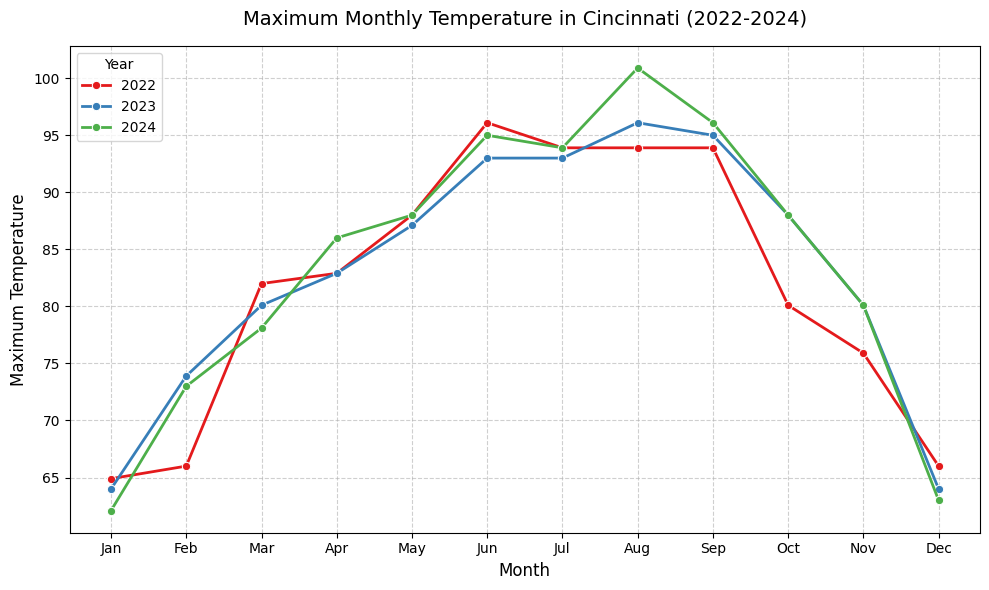

In [18]:
# get the maximum temperature for each month in Cincinnati for 2022, 2023, and 2024
monthly_max_df = (cleaned_cincinnati_df
    .filter(F.year("DATE").isin([2022, 2023, 2024]))
    .withColumn("YEAR", F.year("DATE"))
    .withColumn("MONTH", F.month("DATE"))
    .groupBy("YEAR", "MONTH")
    .agg(F.max("MAX").alias("MAX_TEMP"))
    .orderBy("YEAR", "MONTH")
)

# to pandas for plotting with seaborn and matplotlib
monthly_max_pd_df = monthly_max_df.toPandas()


# plotting the maximum monthly temperature for Cincinnati for 2022, 2023, and 2024 all in one graph with different lines for each year
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=monthly_max_pd_df, 
    x="MONTH", 
    y="MAX_TEMP", 
    hue="YEAR", 
    marker="o",        
    palette="Set1",   
    linewidth=2
)

# Formatting the graph
plt.title("Maximum Monthly Temperature in Cincinnati (2022-2024)", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Maximum Temperature", fontsize=12)

# Set x-axis ticks to show standard month abbreviations instead of numbers 1-12
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(1, 13), labels=months)

# Add gridlines for better readability
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Year", loc='upper left')

plt.tight_layout()
plt.show()

**Our chosen model: using `pyspark.ml` to build a random forest regressor**

In [19]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [20]:
# --- DATA PREPARATION & FEATURE ENGINEERING ----------------------------
# 2022-2023 cincinnati monthly max temp as training data
monthly_stats_df = cleaned_cincinnati_df \
    .filter(F.col("MAX").isNotNull()) \
    .groupBy(F.year("DATE").alias("year"), F.month("DATE").alias("month")) \
    .agg(
        F.max("MAX").alias("monthly_max_temp"),
        F.round(F.sum("PRCP"), 2).alias("monthly_precip"),
        F.round(F.avg("SLP"), 2).alias("monthly_avg_pressure"), # Sea Level Pressure
        F.round(F.avg("DEWP"), 2).alias("monthly_avg_dewp"), # Dew Point
    )

# 1 year and 2 year lag: use self-joins to match a month (e.g., Nov 2024) with its exact counterpart 
# from 1 year ago (Nov 2023) and 2 years ago (Nov 2022).
base_df = monthly_stats_df.alias("base")
lag1_df = monthly_stats_df.alias("lag1")
lag2_df = monthly_stats_df.alias("lag2")

engineered_df = base_df.join(
    lag1_df, 
    (F.col("base.month") == F.col("lag1.month")) & (F.col("base.year") == F.col("lag1.year") + 1), 
    "left"
).join(
    lag2_df, 
    (F.col("base.month") == F.col("lag2.month")) & (F.col("base.year") == F.col("lag2.year") + 2), 
    "left"
).select(
    F.col("base.year"),
    F.col("base.month"),
    F.col("base.monthly_max_temp").alias("label_max"),
    F.col("lag1.monthly_max_temp").alias("lag1_max_temp"),
    F.col("lag2.monthly_max_temp").alias("lag2_max_temp"),
    F.col("lag1.monthly_precip").alias("lag1_precip"),
    F.col("lag2.monthly_precip").alias("lag2_precip"),
    F.col("lag1.monthly_avg_pressure").alias("lag1_pressure"),
    F.col("lag2.monthly_avg_pressure").alias("lag2_pressure"),
    F.col("lag1.monthly_avg_dewp").alias("lag1_dewp"),
    F.col("lag2.monthly_avg_dewp").alias("lag2_dewp"),
).dropna() # Drop any rows (like 2015 and 2016) that don't have 2 previous years of history to look at

# --- TRAIN / TEST SPLIT & VECTOR ASSEMBLY ---------------------------------------------------------
# train on all available historical data up through 2023
train_df = engineered_df.filter(F.col("year") < 2024)

# test on 2024 (The model will predict 2024 based strictly on 2023 and 2022 features)
test_df = engineered_df.filter(F.col("year") == 2024)

# climate features used for training the model
feature_cols = ["month", "lag1_max_temp", "lag2_max_temp", "lag1_precip", "lag1_pressure", "lag1_dewp", "lag2_precip", "lag2_pressure", "lag2_dewp"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
train_data = assembler.transform(train_df).select("features", "label_max")
test_data = assembler.transform(test_df)

# --- MODEL TRAINING ---------------------------------------------------------
# random forest with more trees and slightly deeper to squeeze out more performance given the small dataset (only 12 rows per year)
TRAINING_HYPERPARAMETERS = {
    "numTrees": 150,
    "maxDepth": 6,
    "seed": 42
}
rf = RandomForestRegressor(featuresCol="features", labelCol="label_max", numTrees=TRAINING_HYPERPARAMETERS["numTrees"], maxDepth=TRAINING_HYPERPARAMETERS["maxDepth"], seed=TRAINING_HYPERPARAMETERS["seed"])
model = rf.fit(train_data)

# --- MODEL EVALUATION ---------------------------------------------------------
print("============= MODEL EVALUATION REPORT =============")

# Run predictions on the 2024 testing set
predictions = model.transform(test_data)

# Calculate rmse and mae 
rmse_evaluator = RegressionEvaluator(labelCol="label_max", predictionCol="prediction", metricName="rmse")
mae_evaluator = RegressionEvaluator(labelCol="label_max", predictionCol="prediction", metricName="mae")

rmse = rmse_evaluator.evaluate(predictions)
mae = mae_evaluator.evaluate(predictions)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °F")
print(f"Mean Absolute Error (MAE):      {mae:.2f} °F")

# --- PREDICTION REPORT ---------------------------------------------------------
print("============= MODEL EVALUATION REPORT =============")

final_forecast = predictions \
    .filter(F.col("month").isin([11, 12])) \
    .select(
        F.col("month").alias("Month"),
        F.round(F.col("label_max"), 2).alias("True_Actual_Max_Temp"),
        F.round(F.col("prediction"), 2).alias("Predicted_Max_Temp"),
        F.round(F.abs(F.col("label_max") - F.col("prediction")), 2).alias("Error_Margin")
    ) \
    .orderBy("Month")

final_forecast.show()

============= MODEL EVALUATION REPORT =============

Root Mean Squared Error (RMSE): 4.22 °F

Mean Absolute Error (MAE):      3.53 °F

============= MODEL EVALUATION REPORT =============

+-----+--------------------+------------------+------------+
|Month|True_Actual_Max_Temp|Predicted_Max_Temp|Error_Margin|
+-----+--------------------+------------------+------------+
|   11|                80.1|             75.78|        4.32|
|   12|                63.0|             68.21|        5.21|
+-----+--------------------+------------------+------------+



In [21]:
# Stop the session when ompletely done with the notebook
spark.stop()